# Linear regression

In [83]:
import numpy as np
import matplotlib.pyplot as plt

In [178]:
def train(x, Y):
    """
    Trains a linear regression model.
    
    Args:
        x (np.ndarray): Feature vector of shape (N,).
        Y (np.ndarray): Target values vector of shape (N,).
        
    Returns:
        np.ndarray: Weights.
    """
    if x.ndim == 1:
        # Features matrix with bias 
        X = np.column_stack((np.ones(len(x)), x))
    
    else:
        ones = np.ones((x.shape[0], 1))
        X = np.hstack([ones, x])
        
    # Model weights
    w = np.linalg.inv(X.T @ X) @ X.T @ Y
    
    return w

In [176]:
def find_MSE(Y, Y_pred):
    """ 
     Calculates Mean Squared Error (MSE).
    
     Args:
         Y (np.ndarray): Actual target values.
         Y_pred (np.ndarray): Predicted target values.
        
     Returns:
         float: The MSE value.
    """
    return np.mean((Y - Y_pred) ** 2)

In [179]:
# Feature range
x = np.arange(1, 25, 0.1)

# Define bias
bias = 12

# Generate target values with noise
Y =  bias + x + np.random.normal(1, 3, len(x))

# Calculating weights vector
weights = train(x, Y)

# Fitted model 
model_a = lambda x: weights[0] + weights[1] * x

# Make predictions on the training data
y_pred = model_a(x)

# Calculating of MSE
MSE = find_MSE(Y, y_pred)

In [180]:
print(f"model MSE: {MSE:.3f}\n")
print(f"model bias: {weights[0]:.3f} model slope: {weights[1]:.3f}")

model MSE: 10.166

model bias: 12.972 model slope: 1.016


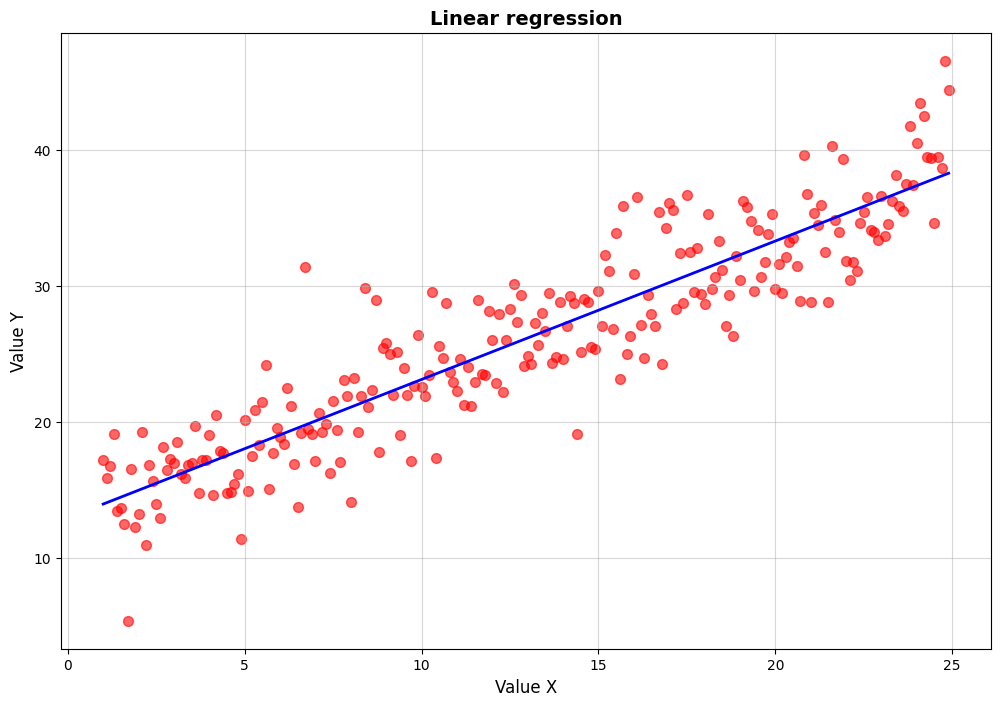

In [181]:
plt.figure(figsize=(12, 8))
plt.scatter(x, Y, color='red', alpha=0.6, s=50)
plt.xlabel("Value X", fontsize=12) 
plt.ylabel("Value Y", fontsize=12) 
plt.title("Linear regression", fontsize=14, fontweight='bold')
plt.plot(x, y_pred, color='blue', linewidth=2)
plt.grid(True, linestyle='-', alpha=0.5)

In [182]:
# Creating data
bias = 11
x = np.arange(0, 300, 0.5)
Y = bias + np.sin(x) + np.cos(6 * x) + x + np.random.normal(1, 12, len(x))

# Fitting model b 
weights_b = train(x, Y)
model_b = lambda x: weights_b[0] + x * weights_b[1] 
y_pred_b = model_b(x)

# Printing metrics
MSE_b = find_MSE(Y, y_pred_b)
print(f"MSE of b model:{MSE_b:.3f}\n")
print(f"model b bias: {weights_b[0]:.3f}, model b slope:{weights_b[1]:.3f}\n")

MSE of b model:141.422

model b bias: 12.585, model b slope:0.999



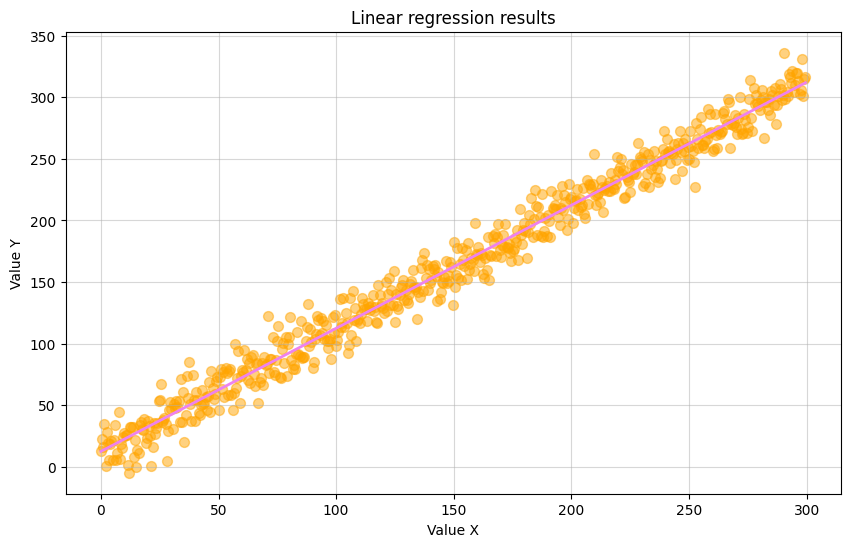

In [183]:
# Visualize data
plt.figure(figsize=(10,6))
plt.xlabel("Value X")
plt.ylabel("Value Y")
plt.scatter(x, Y, color="orange", alpha=0.5, s=50)
plt.plot(x, y_pred_b, color="violet", linewidth=2)
plt.title("Linear regression results")
plt.grid(True, linestyle="-", alpha=0.5)

In [187]:
# Creating data
bias = 12
x = np.arange(0, 300, 0.5)
Y = bias + 300 * np.sin(x) + np.cos(6 * x) + x + np.random.normal(1, 12, len(x))

# Fitting model c
features_c = np.column_stack([np.cos(x), x])
weight_c = train(features_c, Y)
model_c = lambda x: weight_c[0] + np.cos(x) * weight_c[1] + weight_c[2] * x 
y_pred_c = model_c(x)

# Printing metrics
MSE_c = find_MSE(Y, y_pred_c)
print(f"MSE of c model:{MSE_c:.3f}\n")
print(f"model c params: {weights_c[0]:.3f}, {weights_c[1]:.3f}, {weights_c[2]:.3f}")


MSE of c model:44954.474

model c params: 14.354, 0.947, 0.000


Text(0.5, 1.0, 'Polynomial regression')

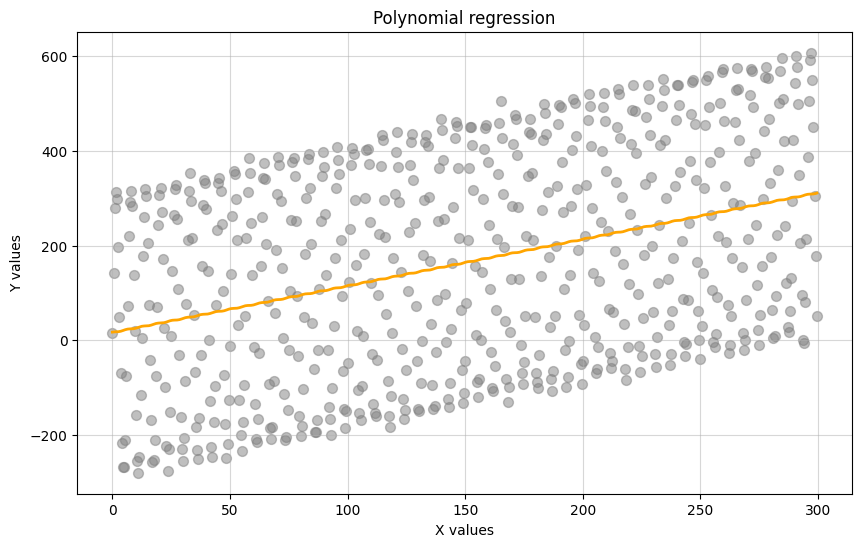

In [188]:
# Visualize data
plt.figure(figsize=(10,6))
plt.scatter(x, Y, color="grey", alpha=0.5, s=50)
plt.plot(x, y_pred_c, color="orange", linewidth=2)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.grid(linestyle="-", alpha=0.5)
plt.title("Polynomial regression")